In [1]:
"""
=================================================
Physics-informed fit: the heat equation
=================================================

A physics-informed neural network (PINN; Raissi, Perdikaris & Karniadakis
2019) represents the solution of a differential equation by a network
``u(x, t)`` and trains it on the equation itself: the loss is the squared
PDE residual at collocation points plus the initial and boundary conditions.
Nothing is solved on a grid; the network's derivatives with respect to its
*inputs* are the ingredients, and the gradient of the residual loss with
respect to the *weights* is what the optimiser needs.

``tttrlib.NeuralNet`` provides both without an autodiff framework:

* ``predict_derivatives(X, V, order)`` carries a directional Taylor expansion
  through the forward pass and returns ``u``, ``∂u/∂v`` and ``∂²u/∂v²`` for the
  direction ``v`` given per sample -- so ``u_t`` is one pass with ``v = (0, 1)``
  and ``u_xx`` one pass with ``v = (1, 0)``;
* ``backward_derivatives`` is the exact adjoint of that: it takes the loss'
  sensitivities to ``u``, ``∂u/∂v`` and ``∂²u/∂v²`` and returns ``dL/dweights``.

The problem here is the one every PINN tutorial starts with,

  ``u_t = α u_xx`` on ``x ∈ [0, 1], t ∈ [0, 1]``, ``u(x, 0) = sin πx``,
  ``u(0, t) = u(1, t) = 0``,

whose solution ``sin(πx) exp(-α π² t)`` is known, so the fit can be scored.
SciPy's L-BFGS-B works on the flat ``parameters`` vector. This is the same
loop the ``test_pinn_poisson_1d`` test runs in one dimension.
"""

"\n=================================================\nPhysics-informed fit: the heat equation\n=================================================\n\nA physics-informed neural network (PINN; Raissi, Perdikaris & Karniadakis\n2019) represents the solution of a differential equation by a network\n``u(x, t)`` and trains it on the equation itself: the loss is the squared\nPDE residual at collocation points plus the initial and boundary conditions.\nNothing is solved on a grid; the network's derivatives with respect to its\n*inputs* are the ingredients, and the gradient of the residual loss with\nrespect to the *weights* is what the optimiser needs.\n\n``tttrlib.NeuralNet`` provides both without an autodiff framework:\n\n* ``predict_derivatives(X, V, order)`` carries a directional Taylor expansion\n  through the forward pass and returns ``u``, ``∂u/∂v`` and ``∂²u/∂v²`` for the\n  direction ``v`` given per sample -- so ``u_t`` is one pass with ``v = (0, 1)``\n  and ``u_xx`` one pass with ``v =

In [2]:
import json

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import tttrlib

rng = np.random.default_rng(1)
alpha = 0.1


def make_net(dims, activation="tanh", seed=0):
    """An untrained network of the given widths, Glorot-initialised, no scalers.

    ``NeuralNet.train`` fits the scalers itself; a network that will be trained
    on a residual is best built explicitly, through the JSON loader.
    """
    r = np.random.default_rng(seed)
    layers = []
    for i in range(len(dims) - 1):
        n_in, n_out = dims[i], dims[i + 1]
        w = r.normal(size=(n_out, n_in)) * np.sqrt(2.0 / (n_in + n_out))
        layers.append({"n_in": n_in, "n_out": n_out,
                       "activation": activation if i < len(dims) - 2 else "identity",
                       "weight": w.ravel().tolist(), "bias": [0.0] * n_out})
    return tttrlib.NeuralNet.from_json_string(json.dumps(
        {"format": "tttrlib.neural_net", "version": 1, "layers": layers}))

In [3]:
# Collocation points, initial and boundary data
# ---------------------------------------------
n_f = 1000
X_f = np.column_stack([rng.uniform(0, 1, n_f), rng.uniform(0, 1, n_f)])   # (x, t)
X_i = np.column_stack([np.linspace(0, 1, 50), np.zeros(50)])
U_i = np.sin(np.pi * X_i[:, :1])
X_b = np.column_stack([np.r_[np.zeros(25), np.ones(25)], np.tile(np.linspace(0, 1, 25), 2)])
U_b = np.zeros((50, 1))
X_d = np.vstack([X_i, X_b])          # everything with a known value
U_d = np.vstack([U_i, U_b])

e_x = np.tile([[1.0, 0.0]], (n_f, 1))   # direction for u_x, u_xx
e_t = np.tile([[0.0, 1.0]], (n_f, 1))   # direction for u_t

net = make_net([2, 16, 16, 1])

In [4]:
# The loss and its gradient
# -------------------------
# Residual ``r = u_t - α u_xx`` at the collocation points, squared and
# averaged, plus the mean squared misfit at the data points. Its gradient is
# assembled from three backward calls, one per forward pass -- the adjoint of
# ``r`` with respect to ``u_xx`` is ``-α · 2r/n`` (an ``order-2`` sensitivity
# along ``e_x``), with respect to ``u_t`` it is ``2r/n`` (an ``order-1``
# sensitivity along ``e_t``), and the data term is a plain ``backward``.
history = []


def objective(p):
    net.parameters = p
    _, _, u_xx = net.predict_derivatives_np(X_f, e_x, order=2)
    _, u_t, _ = net.predict_derivatives_np(X_f, e_t, order=1)
    u_d, _, _ = net.predict_derivatives_np(X_d, order=0)
    r = u_t - alpha * u_xx
    loss = np.mean(r ** 2) + np.mean((u_d - U_d) ** 2)
    g_xx, _, _ = net.backward_np(X_f, np.zeros_like(r), V=e_x, dY2=-alpha * 2 * r / r.size)
    g_t, _, _ = net.backward_np(X_f, np.zeros_like(r), V=e_t, dY1=2 * r / r.size)
    g_d, _, _ = net.backward_np(X_d, 2 * (u_d - U_d) / U_d.size)
    history.append(loss)
    return loss, g_xx + g_t + g_d


res = minimize(objective, net.parameters, jac=True, method="L-BFGS-B",
               options={"maxiter": 1000, "maxfun": 2000, "ftol": 1e-15, "gtol": 1e-12})
net.parameters = res.x
print("L-BFGS: %d iterations, loss %.2e (%s)" % (res.nit, res.fun, res.message))

L-BFGS: 1000 iterations, loss 1.64e-05 (STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT)


max |u_net - u_exact| on a 101 x 101 grid: 4.98e-03


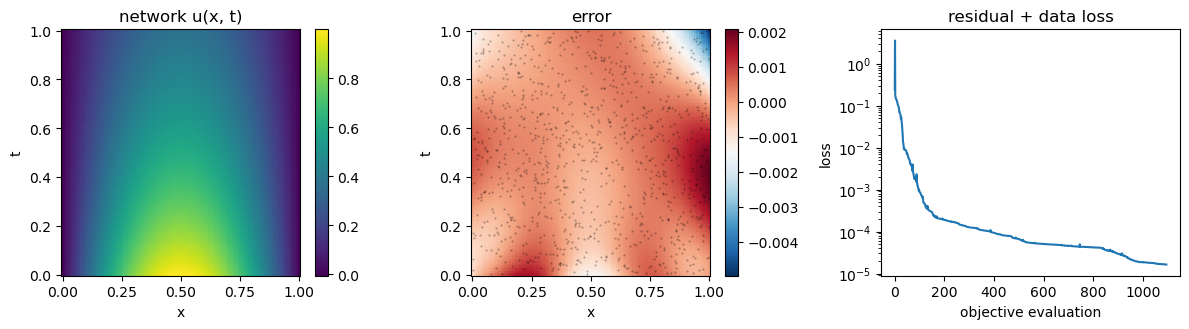

In [5]:
# Against the analytic solution
# -----------------------------
xg, tg = np.meshgrid(np.linspace(0, 1, 101), np.linspace(0, 1, 101))
XT = np.column_stack([xg.ravel(), tg.ravel()])
u_net = net.predict_batch_np(XT).reshape(xg.shape)
u_ex = np.sin(np.pi * xg) * np.exp(-alpha * np.pi ** 2 * tg)
print("max |u_net - u_exact| on a 101 x 101 grid: %.2e" % np.abs(u_net - u_ex).max())

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
im = ax[0].pcolormesh(xg, tg, u_net, shading="auto")
ax[0].set_title("network u(x, t)")
plt.colorbar(im, ax=ax[0])
im = ax[1].pcolormesh(xg, tg, u_net - u_ex, shading="auto", cmap="RdBu_r")
ax[1].set_title("error")
plt.colorbar(im, ax=ax[1])
ax[1].plot(X_f[:, 0], X_f[:, 1], "k.", ms=1, alpha=0.3)
for a in ax[:2]:
    a.set_xlabel("x"), a.set_ylabel("t")
ax[2].semilogy(history)
ax[2].set_xlabel("objective evaluation"), ax[2].set_ylabel("loss")
ax[2].set_title("residual + data loss")
plt.tight_layout()

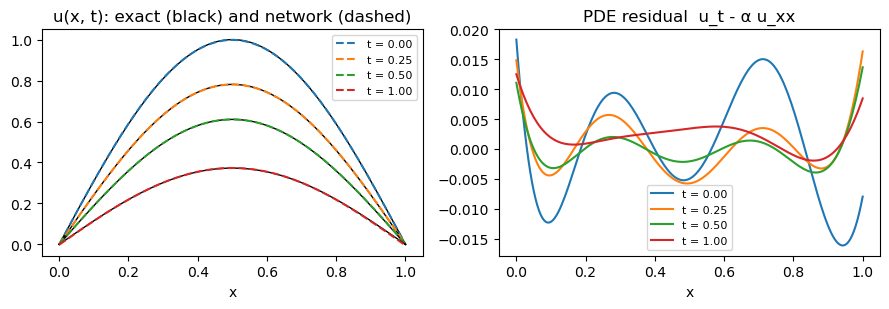

In [6]:
# Slices in time, with the residual the network is actually minimising:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
xs = np.linspace(0, 1, 200)
for t in (0.0, 0.25, 0.5, 1.0):
    XTs = np.column_stack([xs, np.full_like(xs, t)])
    ax[0].plot(xs, np.sin(np.pi * xs) * np.exp(-alpha * np.pi ** 2 * t), "k-", lw=1)
    ax[0].plot(xs, net.predict_batch_np(XTs), "--", label="t = %.2f" % t)
    _, _, uxx = net.predict_derivatives_np(XTs, np.tile([[1.0, 0.0]], (len(xs), 1)), order=2)
    _, ut, _ = net.predict_derivatives_np(XTs, np.tile([[0.0, 1.0]], (len(xs), 1)), order=1)
    ax[1].plot(xs, ut - alpha * uxx, label="t = %.2f" % t)
ax[0].set_title("u(x, t): exact (black) and network (dashed)")
ax[1].set_title("PDE residual  u_t - α u_xx")
for a in ax:
    a.legend(fontsize=8)
    a.set_xlabel("x")
plt.tight_layout()
plt.show()